In [28]:
from skimage import io, img_as_ubyte
from PIL import Image
import numpy as np
import os

def halftone(img_name, convert_to_byte=True):
    img = Image.open(img_name)
    img = img.resize([i//2*2 for i in img.size])
    img_arr = np.array(img.convert("1"))
    if convert_to_byte:
        return img_as_ubyte(img_arr)
    return img_arr

def basic_vcs2(img_name="lena.png"):
    img_arr = halftone(img_name)
    share1 = np.zeros((img_arr.shape[0],2*img_arr.shape[1]),bool)
    share1[:][::2]=True
    share2 = np.zeros_like(share1)
    for (i, j), p in np.ndenumerate(img_arr):
            if p:
                share2[i, 2*j:2*(j+1)] = share1[i, 2*j:2*(j+1)]
            else:
                share2[i, 2*j:2*(j+1)] = np.invert(share1[i, 2*j:2*(j+1)])
    return share1, share2

In [57]:
img_name = "./dataset/val/gt_gray/half.jpg"
Image.open(img_name).resize((224,224)).save(img_name)

In [30]:
def basic_rg_vcs(img_name="lena.png", n=2):
    img_arr = np.invert(Image.open(img_name).convert("1"))
    shares = np.zeros((n,)+img_arr.shape, bool)
    for (i, j), p in np.ndenumerate(img_arr):
        if p:
            for ind in range(n):
                shares[ind, i, j] = np.random.choice([True, False])
        else:
            v = np.random.choice([True, False])
            shares[:, i, j] = v
    return shares

def basic_single_vcs(img_name="lena.png", to_save=False):
    img_arr = halftone(img_name)
    share1 = np.random.choice([True, False], img_arr.shape)
    share2 = np.zeros_like(share1)
    for (i, j), p in np.ndenumerate(img_arr):
        if p:
            share2[i, j] = share1[i, j]
        else:
            share2[i, j] = not share1[i, j]
    if to_save:
        basename = os.path.splitext(img_name)[0]
        io.imsave("basic_single_vcs_share1_%s.png" % basename,
                  img_as_ubyte(share1))
        io.imsave("basic_single_vcs_share2_%s.png" % basename,
                  img_as_ubyte(share1))
        io.imsave("basic_single_vcs_decrypted_%s.png" % basename,
                  img_as_ubyte(share1 & share2))
    else:
        return share1, share2
    
def basic_prob_vcs(img_name="lena.png", to_save=False):
    B0 = np.array([[1, 0], [1, 0]], bool)
    B1 = np.array([[0, 1], [1, 0]], bool)
    img_arr = halftone(img_name)
    share1 = np.zeros_like(img_arr, bool)
    share2 = np.zeros_like(img_arr, bool)
    for (i, j), p in np.ndenumerate(img_arr):
        if p:
            (share1[i, j], share2[i, j]) = B0[:, np.random.choice(B0.shape[1])]
        else:
            (share1[i, j], share2[i, j]) = B1[:, np.random.choice(B0.shape[1])]
    if to_save:
        io.imsave("basic_pvcs_decrypted_%s.png" % os.path.splitext(img_name)[0],
                  img_as_ubyte(share1 & share2))
    else:
        return share1, share2

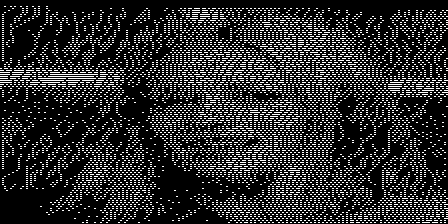

In [31]:
s1, s2 = basic_vcs2(img_name)
Image.fromarray(s1 & s2)

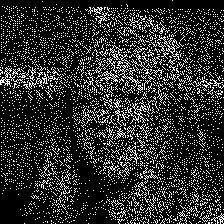

In [50]:
rg = basic_rg_vcs(img_name, 8)
Image.fromarray(rg[0] & rg[1] & rg[2] & rg[3] & rg[4] & rg[5]& rg[6] & rg[7])

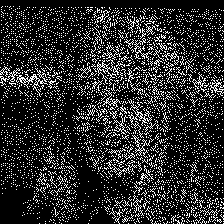

In [51]:
sin1, sin2 = basic_single_vcs(img_name)
Image.fromarray(sin1 & sin2)

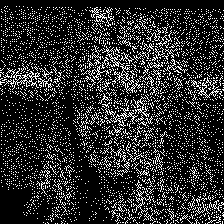

In [53]:
prob1, prob2 = basic_prob_vcs(img_name)
Image.fromarray(prob1 & prob2)

In [58]:
img_arr = halftone(img_name)
Image.fromarray(img_arr).convert('RGB').save('./dataset/val/image_gray/half.jpg')

In [55]:
Image.open('./dataset/val/image_gray/mless.jpg').convert('RGB').save('./dataset/val/image_gray/mless.jpg')